## Middlebury Dataset

In [1]:
import numpy as np
import re
import cv2
import sys
import os
import pandas as pd

def read_pfm(file_path):
    """
    Reads a PFM file (Middlebury Ground Truth Disparity).
    """
    with open(file_path, 'rb') as file:
        header = file.readline().decode('utf-8').rstrip()
        if header == 'PF':
            color = True
        elif header == 'Pf':
            color = False
        else:
            raise Exception('Not a PFM file.')

        dim_match = re.match(r'^(\d+)\s(\d+)\s$', file.readline().decode('utf-8'))
        if dim_match:
            width, height = map(int, dim_match.groups())
        else:
            raise Exception('Malformed PFM header.')

        scale = float(file.readline().decode('utf-8').rstrip())
        
        if scale < 0: # Little-endian
            endian = '<'
            scale = -scale
        else: # Big-endian
            endian = '>'

        data = np.fromfile(file, endian + 'f')
        shape = (height, width, 3) if color else (height, width)

        data = np.reshape(data, shape)
        data = np.flipud(data)

        return data, scale

def parse_middlebury_calib(calib_path):
    """Parses calib.txt."""
    cam_params = {}
    with open(calib_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            if '=' not in line: continue
            key, val = line.split('=')
            val = val.replace('[', '').replace(']', '').replace(';', '')
            values = np.fromstring(val, sep=' ')
            
            if key in ['cam0', 'cam1']:
                cam_params[key] = values.reshape(3, 3)
            elif key in ['doffs', 'baseline', 'width', 'height', 'ndisp', 'vmin', 'vmax']:
                cam_params[key] = values[0]
    return cam_params

class MiddleburyLoader:
    def __init__(self, scene_path, year, downsample_factor=1.0):
        """
        Args:
            scene_path (str): Path to scene.
            year (str): Dataset year.
            downsample_factor (float): 0.5 for half size, 1.0 for full size.
        """
        self.scene_path = scene_path
        self.name = os.path.basename(scene_path)
        self.year = year
        self.scale_factor = downsample_factor
        
    def load_data(self):
        # ... (File path selection logic remains the same) ...
        # [Copy the existing file selection logic from previous prompt here]
        # For brevity, assuming left_path, right_path, disp_path are found:
        
        left_fn = 'im0.png'
        right_fn = 'im1.png'
        gt_fn = 'disp0.pfm'
        
        if self.year == '2001':
            left_fn, right_fn, gt_fn = 'im2.ppm', 'im6.ppm', 'disp2.pgm'
        elif self.year == '2003':
            left_fn, right_fn, gt_fn = 'im2.png', 'im6.png', 'disp2.png'
        elif self.year in ['2005', '2006']:
            left_fn, right_fn, gt_fn = 'view1.png', 'view5.png', 'disp1.png'

        left_path = os.path.join(self.scene_path, left_fn)
        right_path = os.path.join(self.scene_path, right_fn)
        disp_path = os.path.join(self.scene_path, gt_fn)

        # 1. Load Images
        if not os.path.exists(left_path):
             # Handle 2001 ppm/png swaps if needed
             left_path = left_path.replace('.png', '.ppm')
             right_path = right_path.replace('.png', '.ppm')

        left_img = cv2.imread(left_path, cv2.IMREAD_COLOR)
        right_img = cv2.imread(right_path, cv2.IMREAD_COLOR)

        if left_img is None: return None, None, None, None

        # 2. Resize Images (Using INTER_AREA for high-quality shrinking)
        if self.scale_factor != 1.0:
            left_img = cv2.resize(left_img, (0,0), fx=self.scale_factor, fy=self.scale_factor, interpolation=cv2.INTER_AREA)
            right_img = cv2.resize(right_img, (0,0), fx=self.scale_factor, fy=self.scale_factor, interpolation=cv2.INTER_AREA)

        # 3. Load & Resize Ground Truth
        disp_gt = None
        if os.path.exists(disp_path):
            if disp_path.endswith('.pfm'):
                disp_gt, _ = read_pfm(disp_path)
                disp_gt[disp_gt == np.inf] = 0
            else:
                disp_gt = cv2.imread(disp_path, cv2.IMREAD_UNCHANGED)

            # --- CRITICAL RESIZING STEP ---
            if self.scale_factor != 1.0 and disp_gt is not None:
                # A. Spatial Resize: Use NEAREST to avoid blending invalid '0's with valid data
                disp_gt = cv2.resize(disp_gt, (0,0), fx=self.scale_factor, fy=self.scale_factor, interpolation=cv2.INTER_NEAREST)
                
                # B. Value Scaling: Disparity shrinks proportionally to image width
                # Only scale valid pixels (>0) to keep 0 as "Invalid"
                disp_gt = disp_gt.astype(np.float32)
                mask = disp_gt > 0
                disp_gt[mask] *= self.scale_factor

        # 4. Load Calibration (Optional - needs scaling if used)
        calib = None # (Skipping for brevity, usually not needed for basic SAD metrics)

        return left_img, right_img, disp_gt, calib

### Visualize Years 2001, 2003, 2005, 2006, 2014, 2021

In [ ]:
dataset_root = r".\Middlebury_Stereo_Datasets"
data_dic = {"2001": [], "2003": [], "2005": [], "2006": [], "2014": [], '2021': []}

if not os.path.exists(dataset_root):
    print(f"Error: Directory '{dataset_root}' not found. Please create it or change path.")
    sys.exit(1)

for year in sorted(os.listdir(dataset_root)):
    year_path = os.path.join(dataset_root, year)
    if not os.path.isdir(year_path):
        continue

    print(f"\n{'='*20}\nProcessing Year: {year}\n{'='*20}")
    
    scenes = sorted(os.listdir(year_path))
    for scene in scenes:
        scene_dir = os.path.join(year_path, scene)
        if not os.path.isdir(scene_dir):
            continue

        # --- Special Filter for 2003 ---
        if year == "2003" and scene.endswith("F"):
            print(f"Skipping {scene} (ends with F)")
            continue

        try:
            # Pass 'year' to the loader so it knows which naming convention to use
            loader = MiddleburyLoader(scene_dir, year)
            left, right, gt, params = loader.load_data()
            
            print(f"Scene: {loader.name} | Left Shape: {left.shape}", end="")
            if gt is not None:
                print(f" | GT Max: {np.max(gt):.2f} \t | GT Mean: {np.mean(gt[gt>0]):.2f}")
                data_dic[year].append({'scene': scene, 
                                       'left': left, 
                                       'right': right, 
                                       'gt': gt,
                                       'max_disp': np.max(gt),
                                       'params': params})
            else:
                print(" | GT: None")

            # Optional: Uncomment to visualize every image
            
            import matplotlib.pyplot as plt
            plt.figure(figsize=(10, 4))
            plt.subplot(1, 3, 1)
            plt.imshow(cv2.cvtColor(left, cv2.COLOR_BGR2RGB))
            scene_output_path = os.path.join(scene_dir, f"{scene}.png")
            cv2.imwrite(scene_output_path, left)  # Save left image for reference
            plt.title(f"{year} - {scene}")
            if gt is not None:
                plt.subplot(1, 3, 2)
                plt.imshow(gt, cmap='plasma')
                plt.title("Disparity")
            plt.subplot(1, 3, 3)
            plt.imshow(cv2.cvtColor(right, cv2.COLOR_BGR2RGB))
            plt.title("Right Image")
            plt.show()
            
                
        except Exception as e:
            print(f"Error loading {scene}: {e}")

### Matching Algorithms

Compiling Numba functions (first run)...
Execution Only: 15.0943s


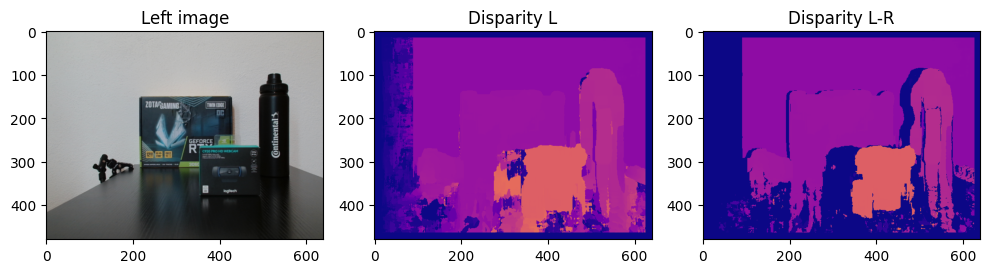

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from numba import njit, prange

# ==========================================
# 1. Numba Optimized Core Logic
# ==========================================

@njit(fastmath=True, cache=True)
def get_subpixel_disparity_jit(costs, d_int, num_disp):
    """
    Refines integer disparity to sub-pixel precision using parabola fitting.
    """
    if d_int <= 0 or d_int >= num_disp - 1:
        return float(d_int)

    c_prev = costs[d_int - 1]
    c_curr = costs[d_int]
    c_next = costs[d_int + 1]

    denom = c_prev + c_next - 2.0 * c_curr
    
    # Avoid division by zero or unstable flats
    if abs(denom) < 1e-5:
        return float(d_int)

    delta = 0.5 * (c_prev - c_next) / denom
    
    # Clamp delta to [-0.5, 0.5] to prevent wild jumps
    if delta > 0.5: delta = 0.5
    elif delta < -0.5: delta = -0.5
        
    return float(d_int) + delta

@njit(fastmath=True, cache=True)
def calculate_cost_jit(left, right, y, x, xr, half_block, metric):
    """
    Computes cost for a single patch pair.
    Metric: 0=SAD, 1=NCC, 2=ZNCC
    """
    # --- SAD (Optimized) ---
    if metric == 0:
        sad = 0.0
        for i in range(-half_block, half_block + 1):
            for j in range(-half_block, half_block + 1):
                val_l = float(left[y+i, x+j])
                val_r = float(right[y+i, xr+j])
                sad += abs(val_l - val_r)
        return sad

    # --- NCC / ZNCC Variables ---
    sum_l = 0.0
    sum_r = 0.0
    sum_sq_l = 0.0
    sum_sq_r = 0.0
    sum_lr = 0.0
    count = 0

    for i in range(-half_block, half_block + 1):
        for j in range(-half_block, half_block + 1):
            val_l = float(left[y+i, x+j])
            val_r = float(right[y+i, xr+j])
            
            sum_l += val_l
            sum_r += val_r
            sum_sq_l += val_l * val_l
            sum_sq_r += val_r * val_r
            sum_lr += val_l * val_r
            count += 1
            
    # --- NCC ---
    if metric == 1:
        denom = np.sqrt(sum_sq_l * sum_sq_r)
        if denom < 1e-6: return 1.0 # Inverted cost (High=Bad)
        score = sum_lr / denom
        return -score # Invert because we minimize cost

    # --- ZNCC ---
    elif metric == 2:
        mean_l = sum_l / count
        mean_r = sum_r / count
        
        numer = 0.0
        denom_l = 0.0
        denom_r = 0.0
        
        for i in range(-half_block, half_block + 1):
            for j in range(-half_block, half_block + 1):
                val_l = float(left[y+i, x+j]) - mean_l
                val_r = float(right[y+i, xr+j]) - mean_r
                numer += val_l * val_r
                denom_l += val_l * val_l
                denom_r += val_r * val_r
                
        denom = np.sqrt(denom_l * denom_r)
        if denom < 1e-6: return 1.0
        score = numer / denom
        return -score

    return 0.0

@njit(parallel=True, fastmath=True, cache=True)
def block_match_jit(img_target, img_ref, num_disparities, block_size, uniqueness_ratio, metric, is_right_view):
    h, w = img_target.shape
    # Output is now float32 for subpixel precision
    disp_map = np.full((h, w), -1.0, dtype=np.float32)
    half = block_size // 2
    
    # Pre-allocate cost buffer logic:
    # We can't pre-allocate one buffer for all threads, so we allocate inside the loop.
    # For small num_disparities (e.g. 64-128), this is very cheap.
    
    for y in prange(half, h - half):
        for x in range(half, w - half):
            
            # Local cost buffer for this pixel
            costs = np.full(num_disparities, 1e9, dtype=np.float32)
            
            best_cost = 1e9
            second_best = 1e9
            best_d = -1
            
            # Search Disparities
            for d in range(num_disparities):
                
                if not is_right_view:
                    x_other = x - d 
                else:
                    x_other = x + d 
                
                if x_other - half < 0 or x_other + half >= w:
                    continue
                
                if not is_right_view:
                    cost = calculate_cost_jit(img_target, img_ref, y, x, x_other, half, metric)
                else:
                    cost = calculate_cost_jit(img_ref, img_target, y, x_other, x, half, metric)

                # Store for subpixel ref later
                costs[d] = cost

                if cost < best_cost:
                    second_best = best_cost
                    best_cost = cost
                    best_d = d
                elif cost < second_best:
                    second_best = cost
            
            # Uniqueness Ratio
            if best_d >= 0:
                thresh = (1.0 - uniqueness_ratio / 100.0) * second_best
                if best_cost <= thresh:
                    # CALCULATE SUBPIXEL HERE
                    sub_d = get_subpixel_disparity_jit(costs, best_d, num_disparities)
                    disp_map[y, x] = sub_d
                    
    return disp_map

@njit(parallel=True, cache=True)
def check_consistency_jit(dL, dR, tol):
    """
    Consistency check compatible with subpixel (float) disparities.
    """
    h, w = dL.shape
    out = np.full((h, w), -1.0, dtype=np.float32)
    
    for y in prange(h):
        for x in range(w):
            d = dL[y, x]
            if d < 0: continue
            
            # Round float disparity to find nearest integer pixel in Right image
            xr = int(round(x - d))
            
            if xr < 0 or xr >= w: continue
            
            d_r = dR[y, xr]
            
            # Compare the float values directly
            if d_r >= 0 and abs(d - d_r) <= tol:
                out[y, x] = d
    return out

@njit(cache=True)
def speckle_filter_jit(disp, max_window, range_thresh):
    h, w = disp.shape
    visited = np.zeros((h, w), dtype=np.int8) 
    valid_mask = np.ones((h, w), dtype=np.int8)
    
    stack_y = [0] * (h*w) 
    stack_x = [0] * (h*w)
    
    dy = [-1, 1, 0, 0]
    dx = [0, 0, -1, 1]

    for y in range(h):
        for x in range(w):
            if disp[y, x] < 0 or visited[y, x]:
                continue
            
            count = 0
            stack_ptr = 0
            
            stack_y[stack_ptr] = y
            stack_x[stack_ptr] = x
            stack_ptr += 1
            visited[y, x] = 1
            
            comp_y = []
            comp_x = []
            
            d0 = disp[y, x]
            
            while stack_ptr > 0:
                stack_ptr -= 1
                cy = stack_y[stack_ptr]
                cx = stack_x[stack_ptr]
                
                comp_y.append(cy)
                comp_x.append(cx)
                count += 1
                
                for i in range(4):
                    ny = cy + dy[i]
                    nx = cx + dx[i]
                    
                    if 0 <= ny < h and 0 <= nx < w:
                        if not visited[ny, nx] and disp[ny, nx] >= 0:
                            # Use float comparison for range
                            if abs(disp[ny, nx] - d0) <= range_thresh:
                                visited[ny, nx] = 1
                                stack_y[stack_ptr] = ny
                                stack_x[stack_ptr] = nx
                                stack_ptr += 1
            
            if count < max_window:
                for k in range(count):
                    valid_mask[comp_y[k], comp_x[k]] = 0
                    
    return valid_mask

# ==========================================
# 2. Wrapper Class
# ==========================================

class StereoBMClone:
    def __init__(self, num_disparities=16, block_size=9,
                 uniqueness_ratio=15, pre_filter_cap=31,
                 speckle_window_size=50, speckle_range=1.0, 
                 similarity="SAD", prefilter_type="sobel"):
        self.num_disparities = num_disparities
        self.block_size = block_size
        self.uniqueness_ratio = uniqueness_ratio
        self.pre_filter_cap = pre_filter_cap
        self.speckle_window_size = speckle_window_size
        self.speckle_range = float(speckle_range) # Ensure float
        self.similarity = similarity.upper()
        self.prefilter_type = prefilter_type.lower()
        
        if self.similarity == "SAD": self.metric_code = 0
        elif self.similarity == "NCC": self.metric_code = 1
        elif self.similarity == "ZNCC": self.metric_code = 2
        else: raise ValueError("Unknown Similarity")

    def prefilter(self, img):
        if self.prefilter_type == "sobel":
            sobel = cv2.Sobel(img, cv2.CV_16S, 1, 0, ksize=3)
            sobel = np.clip(sobel, -self.pre_filter_cap, self.pre_filter_cap)
            return sobel # Signed 16-bit
        elif self.prefilter_type == "gray":
            return img
        # (Other prefilters omitted for brevity, logic assumes signed input for SAD)
        return img

    def compute(self, left, right, lr_check=False, debug=False):
        l_pref = self.prefilter(left)
        r_pref = self.prefilter(right)

        # 1. Match L & R (Returns Float32)
        dispL = block_match_jit(l_pref, r_pref, 
                                self.num_disparities, 
                                self.block_size, 
                                self.uniqueness_ratio, 
                                self.metric_code, 
                                False)

        if not lr_check:
            # Skip further processing
            return dispL, None, dispL
        
        dispR = block_match_jit(r_pref, l_pref, 
                                self.num_disparities, 
                                self.block_size, 
                                self.uniqueness_ratio, 
                                self.metric_code, 
                                True)

        # 2. Consistency (Handles Floats)
        # Note: tol=1.0 is standard, but you might want 0.5 or 1.5 for subpixel
        dispLR = check_consistency_jit(dispL, dispR, tol=1.0)

        # 3. Speckle Filter
        valid_mask = speckle_filter_jit(dispLR, self.speckle_window_size, self.speckle_range)
        
        disp_w_holes = dispLR.copy()
        disp_w_holes[valid_mask == 0] = -2.0 
        
        # 4. Fill holes
        # cv2.inpaint works on float32 images perfectly
        hole_mask = (disp_w_holes <= -1.0).astype(np.uint8) # catch -1 (consistency) and -2 (speckle)
        
        # Ensure non-negative input for visual safety before inpainting, 
        # but inpaint generally handles valid pixels vs mask.
        # We need to make sure the "holes" in the source image aren't confusing the inpainter.
        # Standard practice: Set holes to 0 before inpainting.
        disp_clean_input = disp_w_holes.copy()
        disp_clean_input[hole_mask > 0] = 0
        
        disp_filled = cv2.inpaint(disp_clean_input, hole_mask, 
                                  inpaintRadius=1, flags=cv2.INPAINT_NS)
        if debug and lr_check:
            return dispL, dispR, dispLR, disp_filled
        return dispL, dispR, disp_filled

if __name__ == "__main__":
    # left = cv2.imread(r".\imgs\tsukuba_l.png", cv2.IMREAD_GRAYSCALE)
    # right = cv2.imread(r".\imgs\tsukuba_r.png", cv2.IMREAD_GRAYSCALE)
    # gt_disp_int = cv2.imread(r".\imgs\tsukuba-truedispL.png", cv2.IMREAD_GRAYSCALE)
    # # Convert to floating-point and scale down
    # # This is the crucial step
    # gt = gt_disp_int.astype(np.float32) / 16.0
    # data = data_dic['2014'][4]
    # scene, left, right, gt = data['scene'], data['left'], data['right'], data['gt']
    left = cv2.imread(r"left_20260307-152207.png")
    right = cv2.imread(r"right_20260307-152207.png")

    left_gray = cv2.cvtColor(left, cv2.COLOR_BGR2GRAY)
    right_gray = cv2.cvtColor(right, cv2.COLOR_BGR2GRAY)

    # Initialize
    stereo = StereoBMClone(num_disparities=160, block_size=30,
                           uniqueness_ratio=25, pre_filter_cap=31,
                           speckle_window_size=35, speckle_range=5.0,
                           similarity="NCC", prefilter_type='sobel')
    
    print("Compiling Numba functions (first run)...")
    import time
    s = time.time()
    dL, dR, dLR, dFinal = stereo.compute(left_gray, right_gray, lr_check=True, debug=True)
    print(f"Execution Only: {time.time()-s:.4f}s")
    
    # --- Visualization ---
    gt_vmin, gt_vmax = 0, 256
    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1); plt.title("Left image"); plt.imshow(cv2.cvtColor(left, cv2.COLOR_BGR2RGB), cmap="gray")
    plt.subplot(1,3,2); plt.title("Disparity L"); plt.imshow(dL, cmap="plasma", vmin=gt_vmin, vmax=gt_vmax)
    plt.subplot(1,3,3); plt.title("Disparity L-R"); plt.imshow(dLR, cmap="plasma", vmin=gt_vmin, vmax=gt_vmax)
    plt.tight_layout()
    # plt.savefig("disparity_lr.png",  dpi=80, bbox_inches='tight')

### Compare Function

In [9]:
import numpy as np
import cv2
from typing import Dict, Union, Tuple, Optional

def compare_disparity_maps(
    disp_gt: np.ndarray,
    disp_est: np.ndarray,
    bad_pixel_threshold: float = 2.0
) -> Optional[Tuple[Dict[str, float], np.ndarray]]:
    
    try:
        # --- 1. Sanity Checks ---
        if disp_gt.shape != disp_est.shape:
            print(f"Error: Dimension mismatch {disp_gt.shape} vs {disp_est.shape}")
            return None

        # --- 2. Create Masks ---
        mask_gt_valid = (disp_gt > 0)
        
        if not mask_gt_valid.any():
            return None

        mask_est_valid = (disp_est > 0)

        # --- 3. Compute Correctness Logic ---
        gt_f = disp_gt.astype(np.float32)
        est_f = disp_est.astype(np.float32)
        abs_diff = np.abs(gt_f - est_f)
        
        # Correct: Valid GT + Valid Est + Low Error
        is_correct = (abs_diff <= bad_pixel_threshold) & mask_est_valid & mask_gt_valid
        
        # Bad: Valid GT + (High Error OR Hole)
        is_bad = mask_gt_valid & (~is_correct)

        # --- 4. Metrics ---
        # Bad Pixel Percentage (Standard Middlebury Metric)
        bad_pixel_count = np.sum(is_bad)
        bad_pixel_pct = (bad_pixel_count / mask_gt_valid.sum()) * 100.0
        
        # Error Statistics on VALID GT pixels
        # Note: 'valid_errors' includes errors from holes (where est=0) because we diff against gt_f
        valid_errors = abs_diff[mask_gt_valid]
        
        mae = np.mean(valid_errors)                 # Mean Absolute Error (avgErr)
        mse = np.mean(valid_errors ** 2)            # Mean Squared Error
        rmse = np.sqrt(mse)                         # Root Mean Squared Error (rms)
        
        coverage_pct = (np.sum(mask_est_valid & mask_gt_valid) / mask_gt_valid.sum()) * 100.0

        metrics = {
            "rmse": rmse,                           # <--- Added Standard Middlebury Metric
            "mae": mae,
            "bad_pixel_percentage": bad_pixel_pct,
            "coverage_percentage": coverage_pct,
            "mse": mse                              # Kept for backward compatibility if needed
        }

        # --- 5. Visualization (RGB) ---
        h, w = disp_gt.shape
        sim_map_rgb = np.zeros((h, w, 3), dtype=np.uint8)
        
        # BAD Pixels -> RED
        sim_map_rgb[is_bad] = [255, 0, 0] 
        
        # GOOD Pixels -> GREEN
        sim_map_rgb[is_correct] = [0, 255, 0]
        
        # Invalid GT remains [0,0,0] (Black)

        return metrics, sim_map_rgb

    except Exception as e:
        print(f"Metric calculation failed: {e}")
        return None

### Evaluate Algorithms over Dataset

In [34]:
def run_stereo_benchmark(config, dataset_root=r".\Middlebury_Stereo_Datasets", lr_check=False):
    """
    Executes Stereo Benchmark.
    Updates: Removed MSE (Redundant). Now reports RMSE, MAE, Bad%, Cov%.
    """
    
    # 1. Setup
    dir_name = config.get('dir_name', 'Generic_Test')
    prefilter_mode = config.get('prefilter_type', 'gray')
    
    os.makedirs(dir_name, exist_ok=True)
    print(f"\n{'='*60}")
    print(f" STARTING EXPERIMENT: {dir_name}")
    print(f" Prefilter: {prefilter_mode}")
    print(f"{'='*60}")

    # 2. Warm-Up
    print("Warming up JIT...")
    dummy = np.zeros((30,30), dtype=np.uint8)
    StereoBMClone(num_disparities=16, block_size=9, similarity="SAD").compute(dummy, dummy)

    # 3. Main Loop
    years_to_run = sorted([k for k in config.keys() if k.isdigit()])
    all_raw_results = []

    for year in years_to_run:
        year_path = os.path.join(dataset_root, year)
        if not os.path.exists(year_path):
            print(f"Skipping {year}...")
            continue

        print(f"\n--- Processing Year: {year} ---")

        cfg = config[year]
        downsample = cfg.get('downsample', 1.0) # Default to 1.0 if not specified
        metrics = cfg['metrics']
        max_disp = cfg['max_disp']
        bad_thresh = cfg['bad_pixel_threshold']
        block_size = cfg['block_size']
        scale_rules = cfg['scale']
        
        cfg['results_list'] = []
        
        exp_sub_dir = os.path.join(dir_name, f"Results_{year}")
        os.makedirs(exp_sub_dir, exist_ok=True)
        
        scenes = sorted(os.listdir(year_path))
        
        for scene in scenes:
            scene_dir = os.path.join(year_path, scene)
            if not os.path.isdir(scene_dir): continue
            if year == "2003" and scene.endswith("F"): continue 

            try:
                # --- Load ---
                loader = MiddleburyLoader(scene_dir, year, downsample_factor=downsample)
                left, right, gt, params = loader.load_data()
                if gt is None: continue

                # --- Scale ---
                scale_factor = scale_rules.get('common', 1.0)
                for key in scale_rules:
                    if key != 'common' and key in scene.lower():
                        scale_factor = scale_rules[key]
                        break
                
                gt_ready = gt.astype(np.float32) / scale_factor
                
                print(f"  {scene.ljust(15)} | GT Scale: {scale_factor} | Disp: {max_disp}")

                # --- Images ---
                left_gray = cv2.cvtColor(left, cv2.COLOR_BGR2GRAY)
                right_gray = cv2.cvtColor(right, cv2.COLOR_BGR2GRAY)
                
                row_data = {"Year": year, "Scene": scene}
                vis_maps = {}

                # --- Metric Loop ---
                for metric in metrics:
                    stereo = StereoBMClone(num_disparities=max_disp, block_size=block_size, 
                                           uniqueness_ratio=10, pre_filter_cap=31, 
                                           speckle_window_size=0,
                                           similarity=metric, prefilter_type=prefilter_mode)
                    
                    s = time.time()
                    dL, dR, dFinal = stereo.compute(left_gray, right_gray, lr_check=lr_check)
                    exec_time = time.time() - s
                    
                    if lr_check:
                        dL = dFinal

                    vis_maps[metric] = dL.astype(np.float32)
                    
                    comparison = compare_disparity_maps(gt_ready, dL, bad_pixel_threshold=bad_thresh)
                    
                    if comparison:
                        stats, _ = comparison
                        # REMOVED MSE HERE. Keeping standard Middlebury metrics.
                        row_data[f"{metric}_RMSE"] = stats['rmse']
                        row_data[f"{metric}_MAE"] = stats['mae']
                        row_data[f"{metric}_Bad%"] = stats['bad_pixel_percentage']
                        row_data[f"{metric}_Cov%"] = stats['coverage_percentage']
                        row_data[f"{metric}_Time"] = exec_time

                cfg['results_list'].append(row_data)
                all_raw_results.append(row_data)

                # --- Visualization ---
                mask_valid_gt = gt_ready > 0
                if mask_valid_gt.any():
                    gt_vmin, gt_vmax = gt_ready[mask_valid_gt].min(), gt_ready[mask_valid_gt].max()
                else:
                    gt_vmin, gt_vmax = 0, max_disp

                fig = plt.figure(figsize=(4 * (2 + len(metrics)), 4))
                
                plt.subplot(1, 2 + len(metrics), 1)
                plt.title(f"{scene} (Left)", fontsize=12, fontweight='bold')
                plt.imshow(cv2.cvtColor(left, cv2.COLOR_BGR2RGB))
                plt.axis('off')
                
                plt.subplot(1, 2 + len(metrics), 2)
                plt.title(f"GT", fontsize=11)
                plt.imshow(gt_ready, cmap="plasma", vmin=gt_vmin, vmax=gt_vmax)
                plt.axis('off')
                
                for idx, metric in enumerate(metrics):
                    plt.subplot(1, 2 + len(metrics), 3 + idx)
                    bad_val = row_data.get(f"{metric}_Bad%", 0.0)
                    rmse_val = row_data.get(f"{metric}_RMSE", 0.0)
                    # Updated Title to show RMSE
                    plt.title(f"{metric}\nBad:{bad_val:.1f}% RMS:{rmse_val:.1f}", fontsize=10)
                    
                    v_map = vis_maps[metric].copy()
                    v_map[v_map < 0] = 0
                    plt.imshow(v_map, cmap="plasma", vmin=gt_vmin, vmax=gt_vmax)
                    plt.axis('off')

                plt.tight_layout()
                filename = f"{scene}_compare.png"
                plt.savefig(os.path.join(exp_sub_dir, filename), dpi=80, bbox_inches='tight')
                plt.show()
                plt.close(fig)

            except Exception as e:
                print(f"  Error on {scene}: {e}")

        if cfg['results_list']:
            df_year = pd.DataFrame(cfg['results_list'])
            df_year.to_csv(os.path.join(exp_sub_dir, f"metrics_{year}.csv"), index=False)

    # 4. Final Aggregation
    print("\n" + "-"*30 + "\n Generating Final Aggregated Report \n" + "-" * 30)
    
    if all_raw_results:
        df_all = pd.DataFrame(all_raw_results)
        
        metric_cols = [c for c in df_all.columns if c not in ['Year', 'Scene']]
        for col in metric_cols:
            df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

        df_grouped = df_all.groupby("Year")[metric_cols].mean().reset_index()

        rename_map = {col: col.replace("_Time", "_Time(s)") for col in df_grouped.columns if "_Time" in col}
        df_grouped = df_grouped.rename(columns=rename_map)

        # Updated Column Ordering (Removed MSE)
        cols = list(df_grouped.columns)
        ordered_cols = ["Year"]
        # Order: RMSE, MAE, Bad%, Cov%, Time
        for suffix in ["_RMSE", "_MAE", "_Bad%", "_Cov%", "_Time(s)"]:
            ordered_cols += [c for c in cols if suffix in c]
            
        final_cols = [c for c in ordered_cols if c in df_grouped.columns]
        df_final = df_grouped[final_cols]

        final_csv_path = os.path.join(dir_name, "FINAL_AGGREGATED_RESULTS.csv")
        df_final.to_csv(final_csv_path, index=False, float_format='%.2f')
        
        print(f"Experiment saved to: {dir_name}")
        return df_final
    else:
        print("No results generated.")
        return None

Baseline: Graysacle preprocessing 

In [8]:
# --- Configurations ---
CONF_BASELINE = {
    'dir_name': 'Exp1_Baseline_Raw',
    'prefilter_type': 'gray',
    '2001': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 48,
        'results_list': [],
        'scale': {'tsukuba':16.0, 'common':8.0},
        'bad_pixel_threshold': 1.0,
        'block_size': 15
    },
    '2003': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 48,
        'results_list': [],
        'scale':{'common':4.0},
        'bad_pixel_threshold': 1.0,
        'block_size': 15
    },
    '2005': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 48,
        'results_list': [],
        'scale':{'common': 3.0},
        'bad_pixel_threshold': 1.0,
        'block_size': 15
    },
    '2006': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 48,
        'results_list': [],
        'scale':{'common': 3.0},
        'bad_pixel_threshold': 1.0, 
        'block_size': 15
    },
    '2014': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'downsample': 0.5,        
        'max_disp': 96,           
        'bad_pixel_threshold': 2.0,
        'block_size':30,          
        'results_list': [],
        'scale':{'common': 1.0}
    },
    '2021': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 96,
        'results_list': [],
        'scale':{'common': 1.0},
        'bad_pixel_threshold': 2.0,
        'block_size': 30
    }
}


In [ ]:
df_baseline = run_stereo_benchmark(CONF_BASELINE)
print(df_baseline.to_markdown(index=False, floatfmt=".2f"))

Sobel Preprocessing

In [10]:
# --- Configurations ---
CONF_SOBEL = {
    'dir_name': 'Exp2_Sobel_Prefilter',
    'prefilter_type': 'sobel',
    '2001': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 48,
        'results_list': [],
        'scale': {'tsukuba':16.0, 'common':8.0},
        'bad_pixel_threshold': 1.0,
        'block_size': 15
    },
    '2003': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 48,
        'results_list': [],
        'scale':{'common':4.0},
        'bad_pixel_threshold': 1.0,
        'block_size': 15
    },
    '2005': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 48,
        'results_list': [],
        'scale':{'common': 3.0},
        'bad_pixel_threshold': 1.0,
        'block_size': 15
    },
    '2006': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 48,
        'results_list': [],
        'scale':{'common': 3.0},
        'bad_pixel_threshold': 1.0, 
        'block_size': 15
    },
    '2014': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'downsample': 0.5,        
        'max_disp': 96,           
        'bad_pixel_threshold': 2.0,
        'block_size':30,          
        'results_list': [],
        'scale':{'common': 1.0}
    },
    '2021': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 96,
        'results_list': [],
        'scale':{'common': 1.0},
        'bad_pixel_threshold': 2.0,
        'block_size': 30
    }
}


In [ ]:
df_sobel = run_stereo_benchmark(CONF_SOBEL)
print(df_sobel.to_markdown(index=False, floatfmt=".2f"))

In [23]:
# --- Configurations ---
CONF_SOBEL_DISP_EXT = {
    'dir_name': 'Exp3_Sobel_Prefilter_ExtendedDisp',
    'prefilter_type': 'sobel',
    '2001': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 64,
        'results_list': [],
        'scale': {'tsukuba':16.0, 'common':8.0},
        'bad_pixel_threshold': 1.0,
        'block_size': 15
    },
    '2003': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 64,
        'results_list': [],
        'scale':{'common':4.0},
        'bad_pixel_threshold': 1.0,
        'block_size': 15
    },
    '2005': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 64,
        'results_list': [],
        'scale':{'common': 3.0},
        'bad_pixel_threshold': 1.0,
        'block_size': 15
    },
    '2006': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 64,
        'results_list': [],
        'scale':{'common': 3.0},
        'bad_pixel_threshold': 1.0, 
        'block_size': 15
    },
    '2014': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'downsample': 0.5,        
        'max_disp': 256,           
        'bad_pixel_threshold': 2.0,
        'block_size':30,          
        'results_list': [],
        'scale':{'common': 1.0}
    },
    '2021': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 256,
        'results_list': [],
        'scale':{'common': 1.0},
        'bad_pixel_threshold': 2.0,
        'block_size': 30
    }
}


In [ ]:
df_sobel_ext = run_stereo_benchmark(CONF_SOBEL_DISP_EXT)
print(df_sobel_ext.to_markdown(index=False, floatfmt=".2f"))

In [ ]:
# --- Configurations ---
CONF_SOBEL_DISP_EXT_BS_20 = {
    'dir_name': 'Exp4_Sobel_Prefilter_ExtendedDisp_BS_20',
    'prefilter_type': 'sobel',
    '2014': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'downsample': 0.5,        
        'max_disp': 256,           
        'bad_pixel_threshold': 2.0,
        'block_size':20,          
        'results_list': [],
        'scale':{'common': 1.0}
    },
    '2021': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 256,
        'results_list': [],
        'scale':{'common': 1.0},
        'bad_pixel_threshold': 2.0,
        'block_size': 20
    }
}


In [ ]:
df_sobel_ext_bs_20 = run_stereo_benchmark(CONF_SOBEL_DISP_EXT_BS_20)
print(df_sobel_ext_bs_20.to_markdown(index=False, floatfmt=".2f"))

In [27]:
# --- Configurations ---
CONF_SOBEL_DISP_EXT_BS_40 = {
    'dir_name': 'Exp4_Sobel_Prefilter_ExtendedDisp_BS_40',
    'prefilter_type': 'sobel',
    '2014': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'downsample': 0.5,        
        'max_disp': 256,           
        'bad_pixel_threshold': 2.0,
        'block_size':40,          
        'results_list': [],
        'scale':{'common': 1.0}
    },
    '2021': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 256,
        'results_list': [],
        'scale':{'common': 1.0},
        'bad_pixel_threshold': 2.0,
        'block_size': 40
    }
}


In [ ]:
df_sobel_ext_bs_40 = run_stereo_benchmark(CONF_SOBEL_DISP_EXT_BS_40)
print(df_sobel_ext_bs_40.to_markdown(index=False, floatfmt=".2f"))

In [44]:
# --- Configurations ---
CONF_SOBE_LR = {
    'dir_name': 'Exp6_Sobel_Prefilter_Ext_LRCheck',
    'prefilter_type': 'sobel',
    '2001': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 64,
        'results_list': [],
        'scale': {'tsukuba':16.0, 'common':8.0},
        'bad_pixel_threshold': 1.0,
        'block_size': 15
    },
    '2003': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 64,
        'results_list': [],
        'scale':{'common':4.0},
        'bad_pixel_threshold': 1.0,
        'block_size': 15
    },
    '2005': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 64,
        'results_list': [],
        'scale':{'common': 3.0},
        'bad_pixel_threshold': 1.0,
        'block_size': 15
    },
    '2006': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 64,
        'results_list': [],
        'scale':{'common': 3.0},
        'bad_pixel_threshold': 1.0, 
        'block_size': 15
    },
    '2014': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'downsample': 0.5,        
        'max_disp': 256,           
        'bad_pixel_threshold': 2.0,
        'block_size':30,          
        'results_list': [],
        'scale':{'common': 1.0}
    },
    '2021': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 256,
        'results_list': [],
        'scale':{'common': 1.0},
        'bad_pixel_threshold': 2.0,
        'block_size': 30
    }
}


In [ ]:
df_sobel_lr = run_stereo_benchmark(CONF_SOBE_LR, lr_check=True)
print(df_sobel_lr.to_markdown(index=False, floatfmt=".2f"))

In [41]:
# --- Configurations ---
CONF_SOBE_LR_S_BS = {
    'dir_name': 'Exp5_Sobel_Prefilter_LRCheck_SmallBlock',
    'prefilter_type': 'sobel',
    '2001': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 64,
        'results_list': [],
        'scale': {'tsukuba':16.0, 'common':8.0},
        'bad_pixel_threshold': 1.0,
        'block_size': 10
    },
    '2003': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 64,
        'results_list': [],
        'scale':{'common':4.0},
        'bad_pixel_threshold': 1.0,
        'block_size': 10
    },
    '2005': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 64,
        'results_list': [],
        'scale':{'common': 3.0},
        'bad_pixel_threshold': 1.0,
        'block_size': 10
    },
    '2006': {
        'metrics': ['SAD', 'NCC', 'ZNCC'],
        'max_disp': 64,
        'results_list': [],
        'scale':{'common': 3.0},
        'bad_pixel_threshold': 1.0, 
        'block_size': 10
    }
}


In [ ]:
df_sobel_lr_sb = run_stereo_benchmark(CONF_SOBE_LR_S_BS, lr_check=True)
print(df_sobel_lr_sb.to_markdown(index=False, floatfmt=".2f"))

Focal: 4161.22 px, Baseline: 176.25 mm


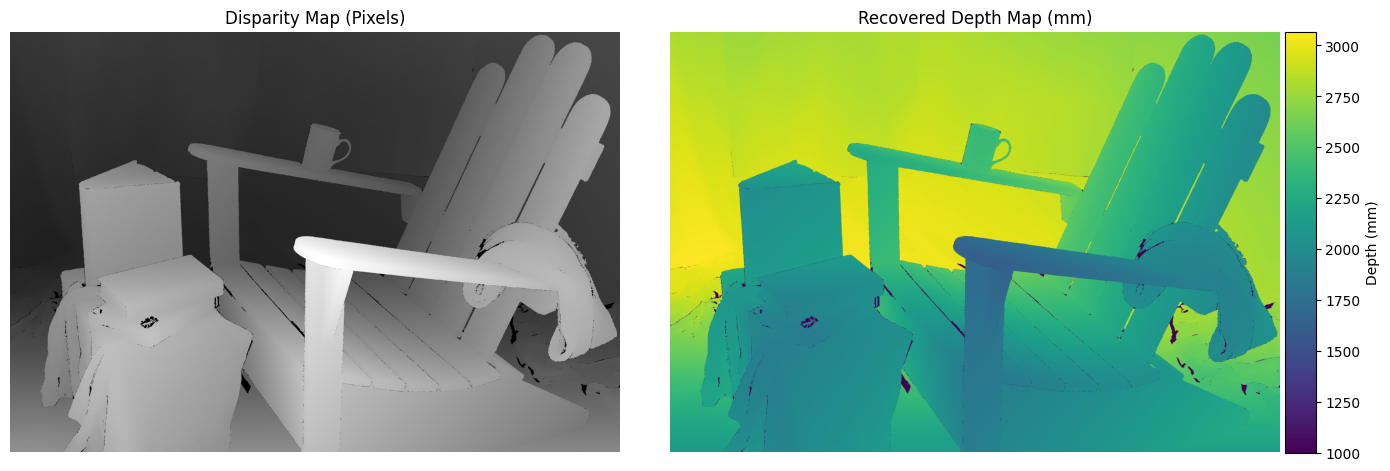

In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from mpl_toolkits.axes_grid1 import make_axes_locatable # <--- IMPORT THIS

# --- Configuration ---
year = "2014"
scene = "Adirondack-perfect" 
root_path = r".\Middlebury_Stereo_Datasets"
scene_dir = os.path.join(root_path, year, scene)

# 1. Load Calibration
def parse_calib(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    params = {}
    for line in lines:
        if '=' in line:
            key, val = line.split('=')
            if '[' in val:
                val = val.replace('[','').replace(']','').replace(';','')
                params[key] = np.fromstring(val, sep=' ').reshape(3,3)
            else:
                params[key] = float(val)
    return params

# 2. Load Data
loader = MiddleburyLoader(scene_dir, year, downsample_factor=1.0)
_, _, gt, _ = loader.load_data()
calib = parse_calib(os.path.join(scene_dir, "calib.txt"))

# 3. Calculate Depth
f = calib['cam0'][0,0]
b = calib['baseline']
doffs = calib['doffs'] 

print(f"Focal: {f:.2f} px, Baseline: {b:.2f} mm")

valid_disp = gt > 0
depth_map = np.zeros_like(gt, dtype=np.float32)
depth_map[valid_disp] = (f * b) / (gt[valid_disp] + doffs)

# 4. Visualization
# Use 'fig, ax' syntax for better control
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Disparity ---
im1 = ax1.imshow(gt, cmap='gray')
ax1.set_title("Disparity Map (Pixels)")
ax1.axis('off')

# To ensure perfect symmetry, we create a divider for ax1 but don't add a colorbar
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="5%", pad=0.05)
cax1.axis('off') # Hide it, just use it to reserve space

# --- Plot 2: Depth ---
# Changed cmap to 'magma_r' (Reverse Magma: Bright=Near, Dark=Far)
im2 = ax2.imshow(depth_map, cmap='viridis', vmin=1000, vmax=depth_map.max())
ax2.set_title("Recovered Depth Map (mm)")
ax2.axis('off')

# Create the specific axis for the colorbar using the divider
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="5%", pad=0.05)

# Draw colorbar in the dedicated axis (cax)
cbar = plt.colorbar(im2, cax=cax2)
cbar.set_label("Depth (mm)")

plt.tight_layout()
plt.savefig(f"{scene}_depth_reconstruction.jpg", dpi=150, bbox_inches='tight')
plt.show()

Compiling Numba functions (first run)...
Execution Only: 1303.8156s


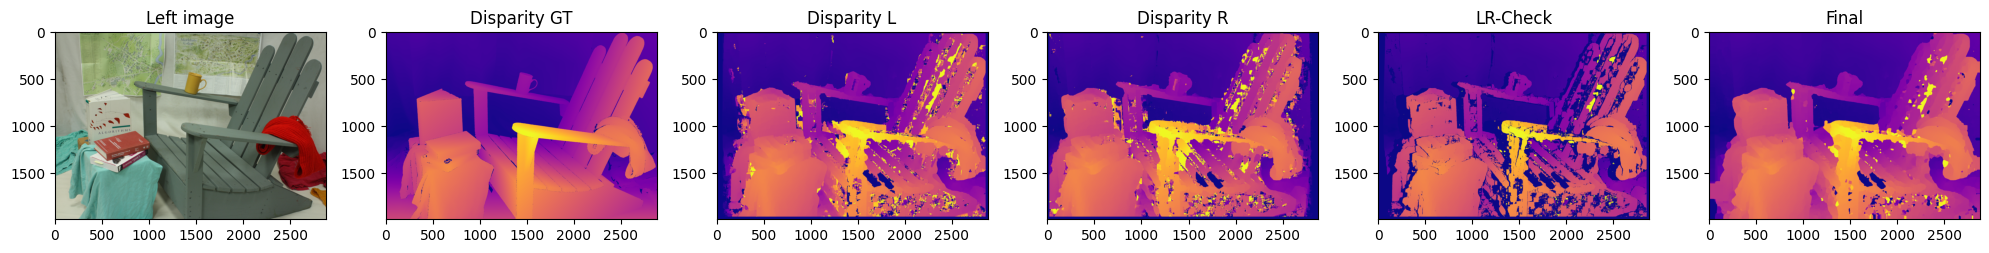

In [11]:
data = data_dic['2014'][0]
scene, left, right, gt = data['scene'], data['left'], data['right'], data['gt']
left_gray = cv2.cvtColor(left, cv2.COLOR_BGR2GRAY)
right_gray = cv2.cvtColor(right, cv2.COLOR_BGR2GRAY)

# Initialize
stereo = StereoBMClone(num_disparities=280, block_size=50,
                        uniqueness_ratio=10, pre_filter_cap=31,
                        speckle_window_size=35, speckle_range=1,
                        similarity="NCC", prefilter_type='sobel')

print("Compiling Numba functions (first run)...")
import time
s = time.time()
dL, dR, dLR, dFinal = stereo.compute(left_gray, right_gray, lr_check=True, debug=True)
print(f"Execution Only: {time.time()-s:.4f}s")

# plt.imshow(dL, cmap='plasma')
# plt.show()
# --- Visualization ---
mask_valid_gt = gt > 0
if mask_valid_gt.any():
    gt_vmin, gt_vmax = gt[mask_valid_gt].min(), gt[mask_valid_gt].max()
else:
    gt_vmin, gt_vmax = 0, 256

# plt.imshow(dFinal, cmap='plasma')
# plt.show()
plt.figure(figsize=(20,8))
plt.subplot(1,6,1); plt.title("Left image"); plt.imshow(cv2.cvtColor(left, cv2.COLOR_BGR2RGB), cmap="gray")
plt.subplot(1,6,2); plt.title("Disparity GT"); plt.imshow(gt, cmap="plasma", vmin=gt_vmin, vmax=gt_vmax)
plt.subplot(1,6,3); plt.title("Disparity L"); plt.imshow(dL, cmap="plasma", vmin=gt_vmin, vmax=gt_vmax)
plt.subplot(1,6,4); plt.title("Disparity R"); plt.imshow(dR, cmap="plasma", vmin=gt_vmin, vmax=gt_vmax)
plt.subplot(1,6,5); plt.title("LR-Check"); plt.imshow(dLR, cmap="plasma", vmin=gt_vmin, vmax=gt_vmax)
plt.subplot(1,6,6); plt.title("Final"); plt.imshow(dFinal, cmap="plasma", vmin=gt_vmin, vmax=gt_vmax)
plt.tight_layout()